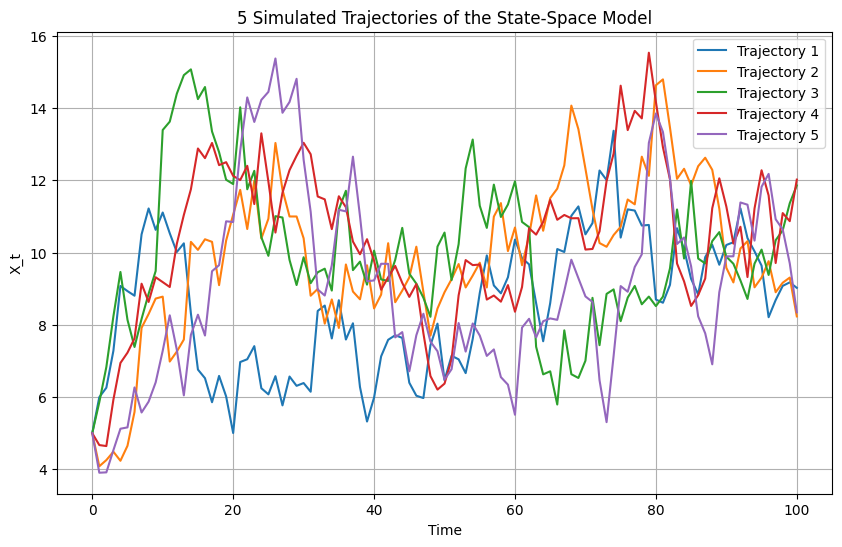

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = 0.9
b = 1
sigma = 1
n = 100
num_paths = 5
X0 = 5

# Set seed for reproducibility
np.random.seed(42)

# Store trajectories
trajectories = np.zeros((num_paths, n+1))

# Simulate
for i in range(num_paths):
    X = np.zeros(n+1)
    X[0] = X0
    for t in range(1, n+1):
        e_t = np.random.normal(0, sigma)
        X[t] = a * X[t-1] + b + e_t
    trajectories[i, :] = X

# Plot
plt.figure(figsize=(10, 6))
for i in range(num_paths):
    plt.plot(trajectories[i], label=f'Trajectory {i+1}')

plt.title('5 Simulated Trajectories of the State-Space Model')
plt.xlabel('Time')
plt.ylabel('X_t')
plt.legend()
plt.grid(True)
plt.show()

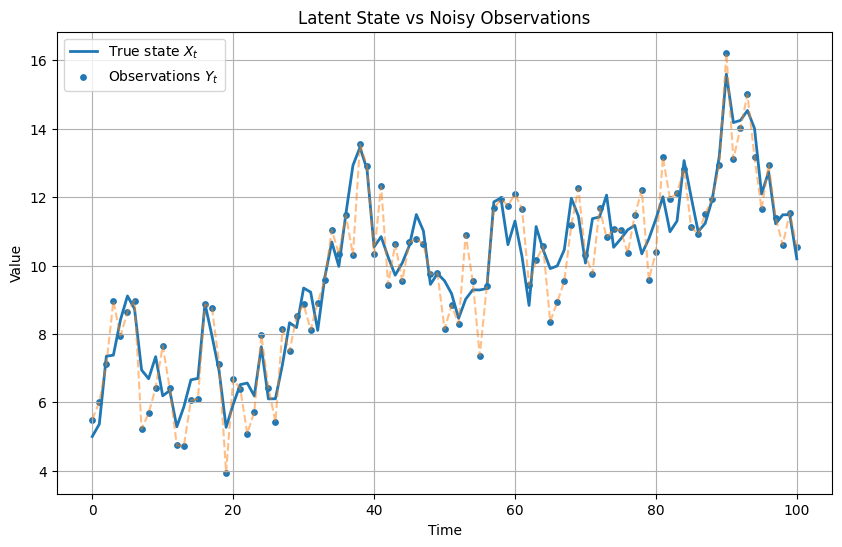

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = 0.9
b = 1
sigma1 = 1   # system noise std
sigma2 = 1   # observation noise std
n = 100
X0 = 5

# Reproducibility
np.random.seed(42)

# Initialize arrays
X = np.zeros(n+1)
Y = np.zeros(n+1)

X[0] = X0
Y[0] = X[0] + np.random.normal(0, sigma2)

# Simulation
for t in range(1, n+1):
    e1 = np.random.normal(0, sigma1)
    e2 = np.random.normal(0, sigma2)
    
    X[t] = a * X[t-1] + b + e1
    Y[t] = X[t] + e2

# Plot
plt.figure(figsize=(10, 6))

# True state (smooth line)
plt.plot(X, label='True state $X_t$', linewidth=2)

# Observations (noisy)
plt.scatter(range(n+1), Y, label='Observations $Y_t$', s=15)
plt.plot(Y, linestyle='--', alpha=0.5)

plt.title('Latent State vs Noisy Observations')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.show()

<>:66: SyntaxWarning: invalid escape sequence '\h'
<>:66: SyntaxWarning: invalid escape sequence '\h'
C:\Users\SanL\AppData\Local\Temp\ipykernel_22880\3934099625.py:66: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(t_axis, x_p, 'b--', label='Predicted State $\hat{X}_{t|t-1}$')


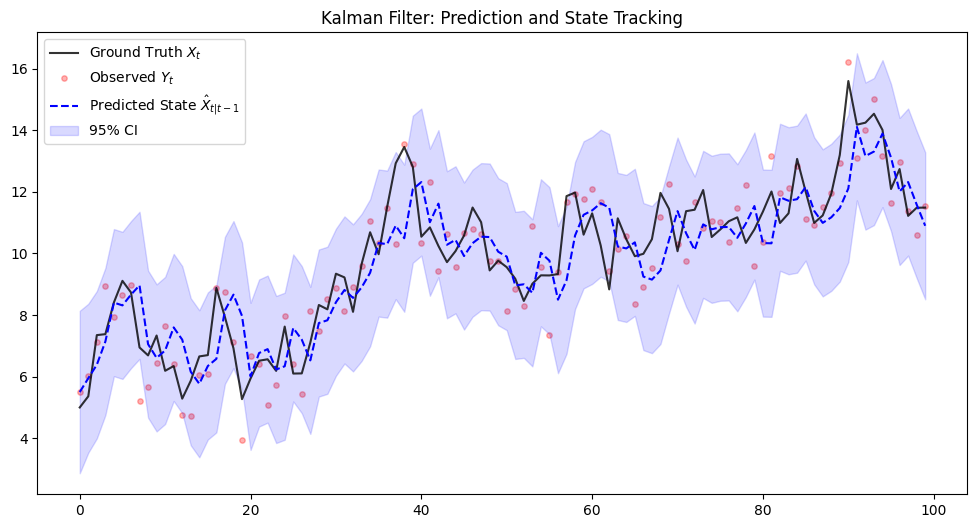

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1.2 DATA SIMULATION ---
np.random.seed(42)
n = 100
a_true, b_true, sigma1, sigma2 = 0.9, 1, 1, 1 # a ist transition, b ist bias
X_true = np.zeros(n)
Y_obs = np.zeros(n)

X_true[0] = 5 
Y_obs[0] = X_true[0] + np.random.normal(0, sigma2)

for t in range(1, n):
    X_true[t] = a_true * X_true[t-1] + b_true + np.random.normal(0, sigma1)
    Y_obs[t] = X_true[t] + np.random.normal(0, sigma2)

# --- 1.3 KALMAN FILTER ---
def myKalmanFilter(y, theta, R, x_prior=5, P_prior=1):
    # Mapping basierend auf deiner Simulation:
    # Xt = a*Xt-1 + b + e
    a = theta[0] # Transition
    b = theta[1] # Bias
    sig1_sq = theta[2]**2
    
    N = len(y)
    x_pred = np.zeros(N); p_pred = np.zeros(N)
    x_filt = np.zeros(N); p_filt = np.zeros(N)
    innovation = np.zeros(N); innovation_var = np.zeros(N)
    
    curr_x_filt = x_prior
    curr_p_filt = P_prior
    
    for t in range(N):
        # 1. Prediction Step (t|t-1)
        x_pred[t] = a * curr_x_filt + b
        p_pred[t] = (a**2) * curr_p_filt + sig1_sq
        
        # 2. Update Step (t|t)
        innovation[t] = y[t] - x_pred[t]
        innovation_var[t] = p_pred[t] + R
        
        K_t = p_pred[t] / innovation_var[t]
        x_filt[t] = x_pred[t] + K_t * innovation[t]
        p_filt[t] = (1 - K_t) * p_pred[t]
        
        # Update für die nächste Iteration
        curr_x_filt = x_filt[t]
        curr_p_filt = p_filt[t]
    
    return x_pred, p_pred, innovation, innovation_var, x_filt, p_filt

# WICHTIG: Reihenfolge [Transition, Bias, Sigma1]
theta_input = [0.9, 1, 1] 
R_val = 1**2

# Funktion aufrufen (direktes Entpacken der Rückgabewerte)
x_p, p_p, inn, inn_v, x_f, p_f = myKalmanFilter(Y_obs, theta_input, R_val)

# --- PLOTTING ---
plt.figure(figsize=(12, 6))
t_axis = np.arange(n)

plt.plot(t_axis, X_true, 'k-', label='Ground Truth $X_t$', alpha=0.8)
plt.scatter(t_axis, Y_obs, color='red', s=15, alpha=0.3, label='Observed $Y_t$')
plt.plot(t_axis, x_p, 'b--', label='Predicted State $\hat{X}_{t|t-1}$')

ci = 1.96 * np.sqrt(p_p)
plt.fill_between(t_axis, x_p - ci, x_p + ci, color='blue', alpha=0.15, label='95% CI')

plt.title("Kalman Filter: Prediction and State Tracking")
plt.legend()
plt.show()

In [4]:
from scipy.optimize import minimize
import math

def myLogLikFun(theta, Y, R, X0, P0):
    # theta: [a, b, sigma1]
    # Ensure sigma1 is positive for numerical stability
    
    # Run your Kalman filter
    # Unpack only what we need (innovation and innovation_var)
    _, _, inn, inn_v, _, _ = myKalmanFilter(Y, theta, R, x_prior=X0, P_prior=P0)
    
    # Log-likelihood for Gaussian innovations:
    # -0.5 * sum(log(2*pi*S) + inn^2/S)
    # We ignore the constant (2*pi) for optimization
    log_lik_elements = -0.5 * (np.log(2*math.pi*inn_v) + (inn**2 / inn_v))
    
    return -np.sum(log_lik_elements) # Negative for minimization

<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
C:\Users\SanL\AppData\Local\Temp\ipykernel_22880\3113210859.py:44: SyntaxWarning: invalid escape sequence '\s'
  axes[i].boxplot(est_results, labels=['a', 'b', '$\sigma_1$'])
C:\Users\SanL\AppData\Local\Temp\ipykernel_22880\3113210859.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(est_results, labels=['a', 'b', '$\sigma_1$'])
C:\Users\SanL\AppData\Local\Temp\ipykernel_22880\3476738818.py:15: RuntimeWarning: overflow encountered in square
  log_lik_elements = -0.5 * (np.log(2*math.pi*inn_v) + (inn**2 / inn_v))
c:\Users\SanL\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\optimize\_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
C:\Users\SanL\AppData\Local\Temp\ipykernel_22880\311321085

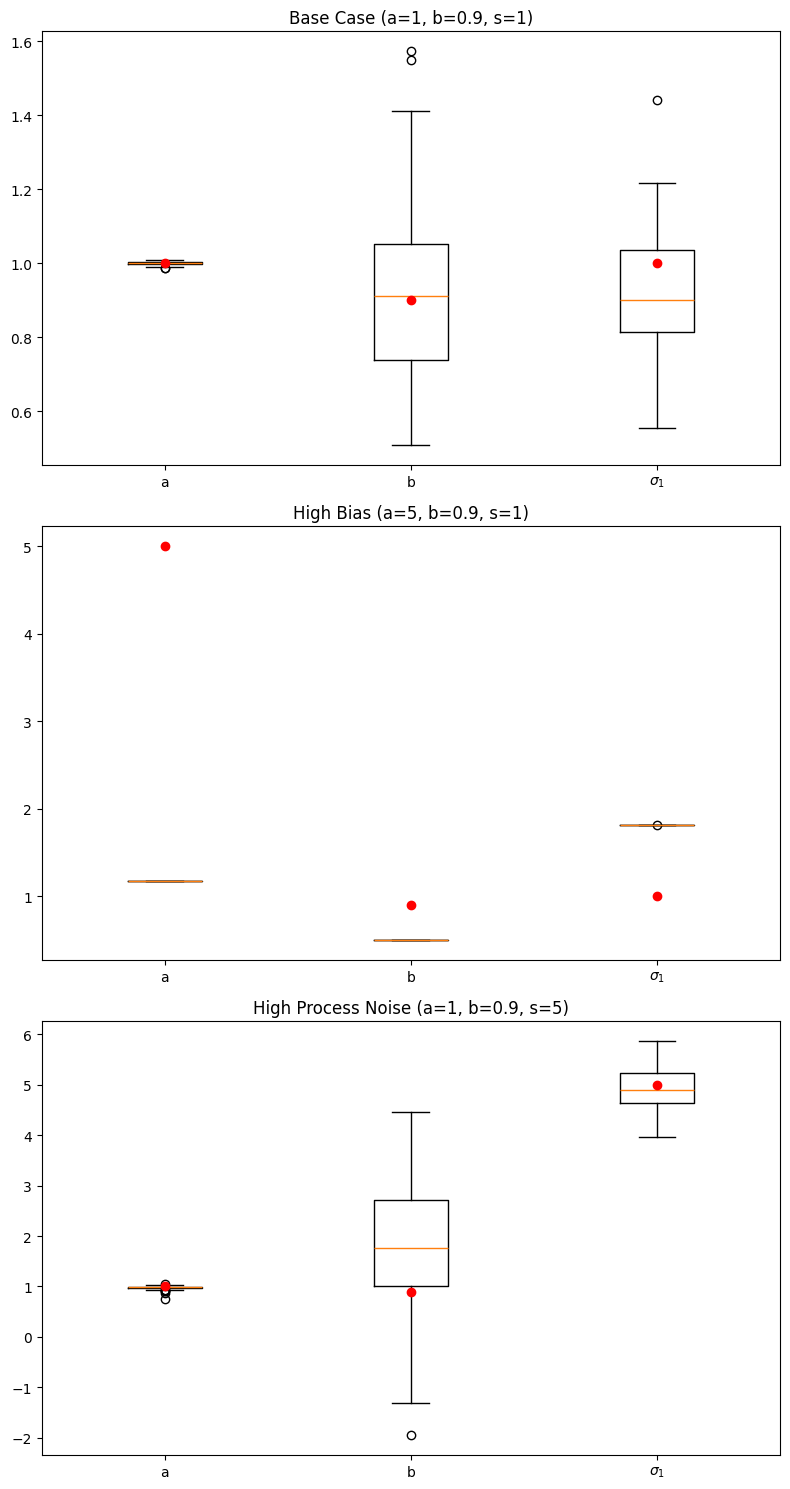

In [5]:
np.random.seed(42)
def run_estimation_study(a_true, b_true, s1_true, s2_val=1, n_sims=100, n_steps=100):
    results = []
    R_fixed = s2_val**2
    
    for _ in range(n_sims):
        # 1. Simulate data
        X = np.zeros(n_steps); Y = np.zeros(n_steps)
        X[0] = 5
        Y[0] = X[0] + np.random.normal(0, s2_val)
        for t in range(1, n_steps):
            X[t] = a_true * X[t-1] + b_true + np.random.normal(0, s1_true)
            Y[t] = X[t] + np.random.normal(0, s2_val)
            
        # 2. Estimate parameters [a, b, sigma1]
        # Initial guess: start near the truth or at neutral values
        init_guess = [0.5, 0.5, 0.5]
        
        # Using L-BFGS-B to provide bounds (especially keeping sigma1 > 0)
        res = minimize(myLogLikFun, init_guess, args=(Y, R_fixed, 5, 1), 
                       method='L-BFGS-B', 
                       bounds=[(None, None), (None, None), (1e-3, None)])
        
        if res.success:
            results.append(res.x)
            
    return np.array(results)

# Define the cases
cases = [
    {"params": [1.0, 0.9, 1.0], "label": "Base Case (a=1, b=0.9, s=1)"},
    {"params": [5.0, 0.9, 1.0], "label": "High Bias (a=5, b=0.9, s=1)"},
    {"params": [1.0, 0.9, 5.0], "label": "High Process Noise (a=1, b=0.9, s=5)"}
]

# Run simulations and plot
fig, axes = plt.subplots(3, 1, figsize=(8, 15))

for i, case in enumerate(cases):
    p = case["params"]
    # Note: mapping adjusted to your code's [a, b, sigma1]
    est_results = run_estimation_study(a_true=p[0], b_true=p[1], s1_true=p[2])
    
    axes[i].boxplot(est_results, labels=['a', 'b', '$\sigma_1$'])
    axes[i].set_title(case["label"])
    # Add red dots for true values
    axes[i].scatter([1, 2, 3], p, color='red', label='True Value', zorder=3)

plt.tight_layout()
plt.show()

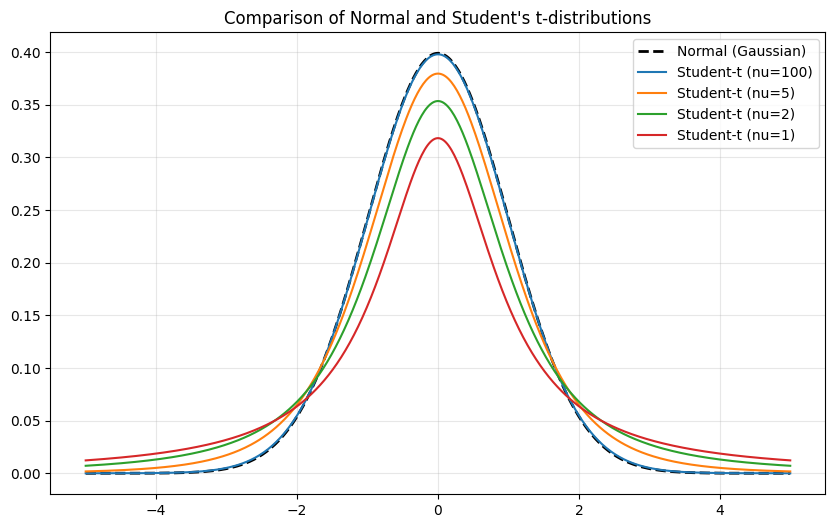

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# --- Plotting the Densities ---
x_axis = np.linspace(-5, 5, 500)
nu_values = [100, 5, 2, 1]

plt.figure(figsize=(10, 6))
plt.plot(x_axis, norm.pdf(x_axis), 'k--', label='Normal (Gaussian)', lw=2)

for nu in nu_values:
    plt.plot(x_axis, t.pdf(x_axis, df=nu), label=f'Student-t (nu={nu})')

plt.title("Comparison of Normal and Student's t-distributions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
np.random.seed(42)

# --- Modified Simulation Function ---
def simulate_t_system(n, a, b, s1, s2, nu):
    X = np.zeros(n)
    Y = np.zeros(n)
    X[0] = 5
    Y[0] = X[0] + np.random.normal(0, s2)
    
    for t_idx in range(1, n):
        # Process noise comes from t-distribution scaled by s1
        process_noise = s1 * np.random.standard_t(df=nu)
        X[t_idx] = a * X[t_idx-1] + b + process_noise
        Y[t_idx] = X[t_idx] + np.random.normal(0, s2)
    return Y

def run_t_study(nu, n_sims=100):
    results = []
    for _ in range(n_sims):
        Y = simulate_t_system(100, 1.0, 0.9, 1.0, 1.0, nu)
        # Re-use your previous optimization logic
        res = minimize(myLogLikFun, [0.5, 0.5, 0.5], args=(Y, 1.0, 5, 1), 
                       method='L-BFGS-B', bounds=[(None, None), (None, None), (1e-3, None)])
        if res.success:
            results.append(res.x)
    return np.array(results)

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
C:\Users\SanL\AppData\Local\Temp\ipykernel_22880\106953080.py:22: SyntaxWarning: invalid escape sequence '\s'
  axes[i].boxplot(data, labels=['a', 'b', '$\sigma_1$'])


Starte Simulation für nu = 100...
Starte Simulation für nu = 5...
Starte Simulation für nu = 2...
Starte Simulation für nu = 1...


C:\Users\SanL\AppData\Local\Temp\ipykernel_22880\106953080.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=['a', 'b', '$\sigma_1$'])
C:\Users\SanL\AppData\Local\Temp\ipykernel_22880\106953080.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=['a', 'b', '$\sigma_1$'])
C:\Users\SanL\AppData\Local\Temp\ipykernel_22880\106953080.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=['a', 'b', '$\sigma_1$'])
C:\Users\SanL\AppData\Local\Temp\ipykernel_22880\106953080.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of bo

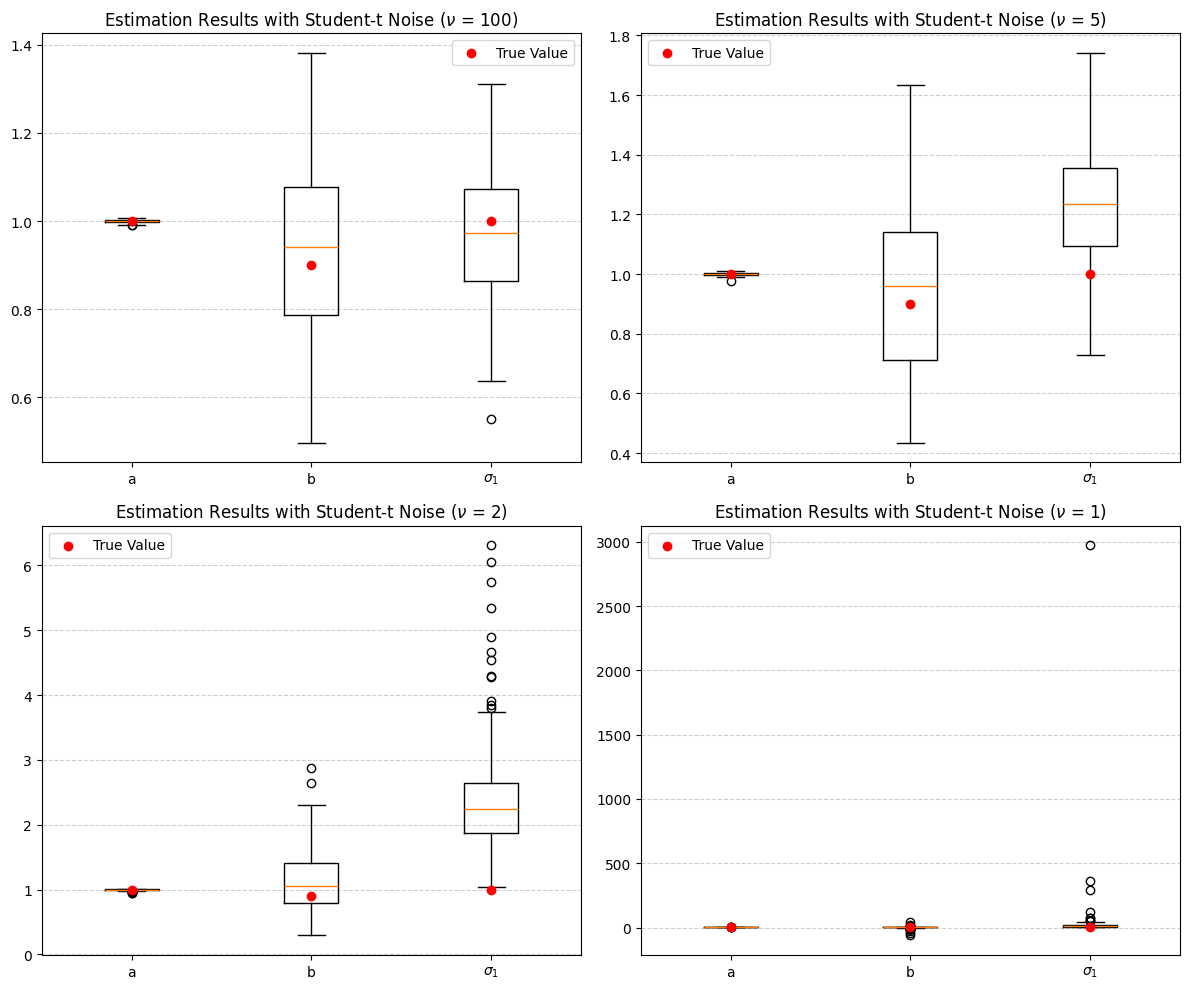

In [7]:
# --- Durchführung der Student-t Studie ---
np.random.seed(42)
nu_values = [100, 5, 2, 1]
t_study_results = {}

# Daten sammeln
for nu in nu_values:
    print(f"Starte Simulation für nu = {nu}...")
    t_study_results[nu] = run_t_study(nu)

# --- Plotten der Ergebnisse ---

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # wichtig, damit du wie bisher linear zugreifen kannst

p_true = [1.0, 0.9, 1.0]

for i, nu in enumerate(nu_values):
    data = t_study_results[nu]
    
    # Boxplot
    axes[i].boxplot(data, labels=['a', 'b', '$\sigma_1$'])
    axes[i].set_title(f"Estimation Results with Student-t Noise ($\\nu$ = {nu})")
    
    # Wahre Werte markieren
    axes[i].scatter([1, 2, 3], p_true, color='red', label='True Value', zorder=3)
    
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)
    axes[i].legend()

plt.tight_layout()
plt.show()

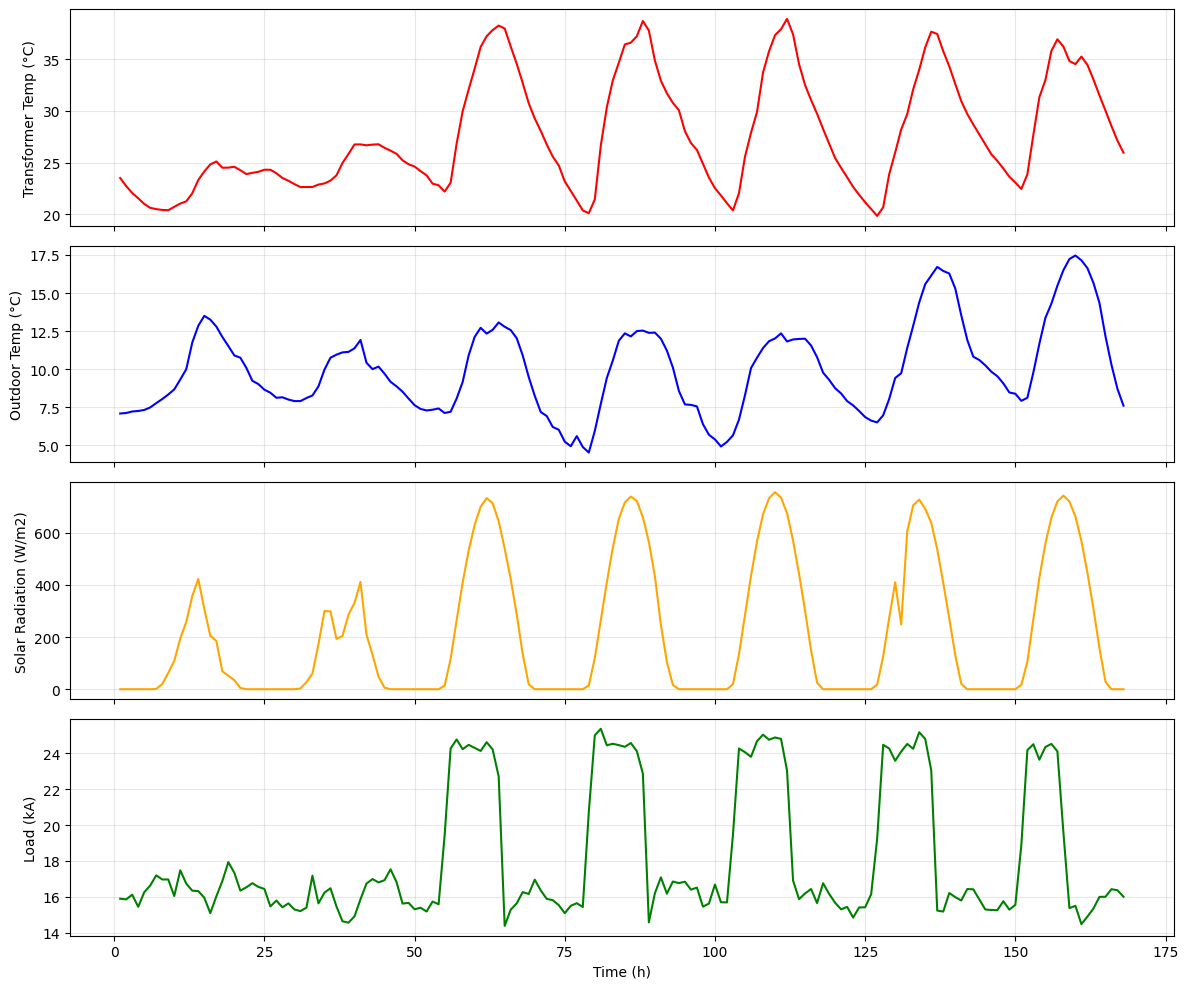

In [8]:
import pandas as pd

df = pd.read_csv("transformer_data.csv")

t = df["time"]
Yt = df["Y"]
Ta = df["Ta"]
S = df["S"]
I = df["I"]


fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

variables = [('Y', 'Transformer Temp (°C)', 'red'), 
             ('Ta', 'Outdoor Temp (°C)', 'blue'), 
             ('S', 'Solar Radiation (W/m2)', 'orange'), 
             ('I', 'Load (kA)', 'green')]

for i, (col, label, color) in enumerate(variables):
    axs[i].plot(df['time'], df[col], color=color)
    axs[i].set_ylabel(label)
    axs[i].grid(True, alpha=0.3)

axs[-1].set_xlabel('Time (h)')
plt.tight_layout()
plt.show()

Optimization success: True
Estimated parameters:
[ 8.00966428e-01  1.01117784e-01  2.84840069e-03  2.11471844e-01
  6.38512929e-01  1.00920973e+00 -2.21086052e-05  2.35609502e+01]

A = 0.8009664280384607
B = [0.10111778 0.0028484  0.21147184]   [Ta, Solar, Load]
G = 0.6385129286873501
C = 1.0092097347578397
sigma_y = 2.2108605200151525e-05


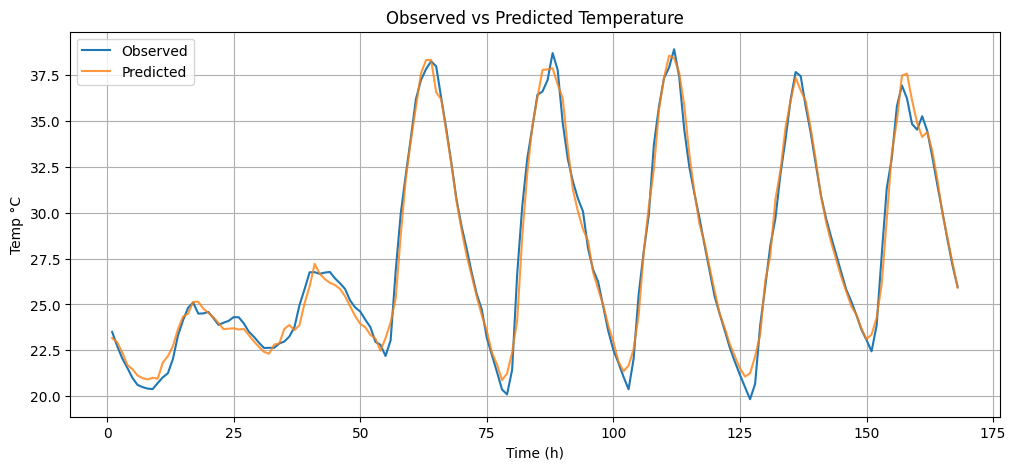

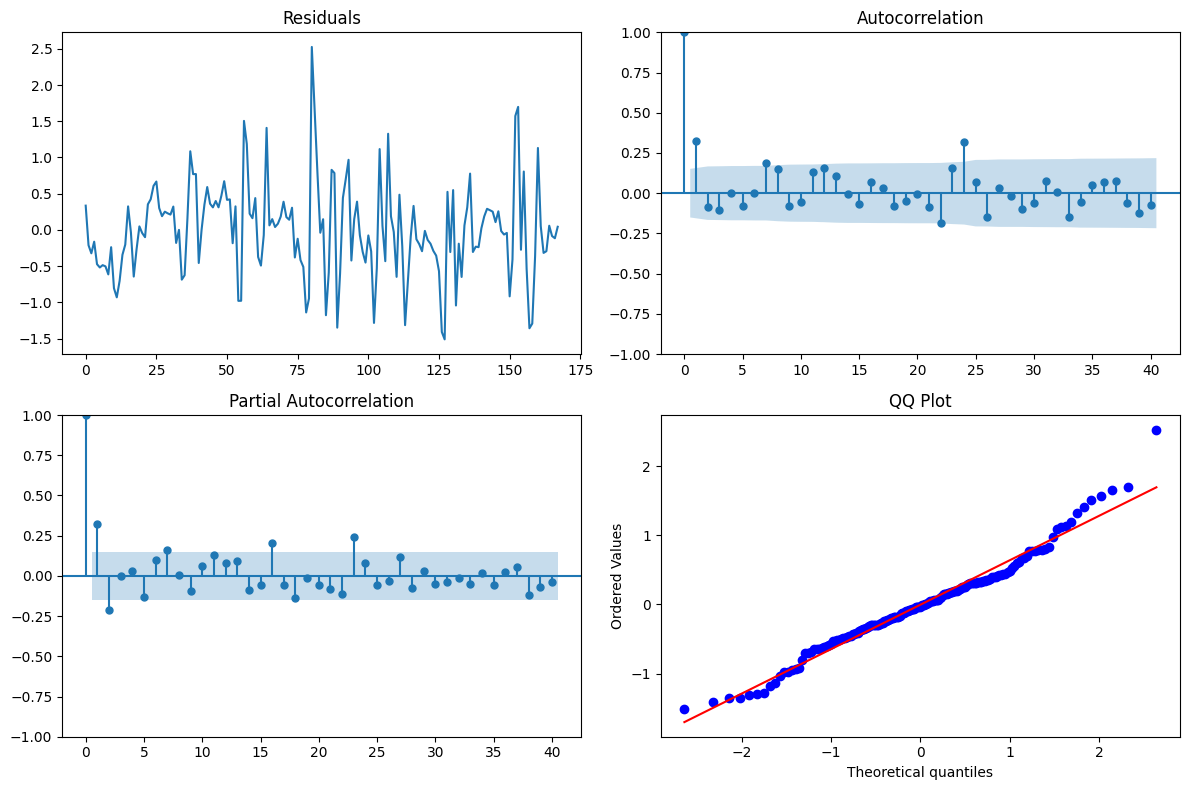


LogLik = -165.50061946462768
AIC = 347.00123892925535
BIC = 371.9929507644814


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import probplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==========================================================
# LOAD DATA
# ==========================================================
df = pd.read_csv("transformer_data.csv")

# Ensure columns exist: time, Y, Ta, S, I
t = df["time"].values
Y = df["Y"].values.reshape(-1, 1)
U = df[["Ta", "S", "I"]].values



# ==========================================================
# 2.2 1-DIMENSIONAL STATE SPACE MODEL
#
# X[t+1] = A X[t] + B u[t] + G e1[t]
# Y[t]   = C X[t] + e2[t]
#
# State dimension = 1
# ==========================================================

def kalman_loglik(par, df):
    """
    Parameter vector:
    par = [A, b1, b2, b3, G, C, sigma_y, x0]
    """
    A      = par[0]
    B      = np.array(par[1:4]).reshape(1, 3)
    G      = abs(par[4])
    C      = par[5]
    sigma_y = abs(par[6])
    x0     = par[7]

    # Covariances
    Q = np.array([[G**2]])
    R = np.array([[sigma_y**2]])

    Y = df["Y"].values.reshape(-1, 1)
    U = df[["Ta", "S", "I"]].values

    Tn = len(df)

    # Initial state
    x_est = np.array([[x0]])
    P_est = np.array([[10.0]])

    logLik = 0.0

    for t in range(Tn):

        u_t = U[t].reshape(3, 1)
        y_t = Y[t].reshape(1, 1)

        # -------------------------
        # Prediction step
        # -------------------------
        x_pred = A * x_est + B @ u_t
        P_pred = A * P_est * A + Q

        # -------------------------
        # Innovation step
        # -------------------------
        y_pred = C * x_pred
        S_t = C * P_pred * C + R
        innov = y_t - y_pred

        # Log-likelihood
        logLik += -0.5 * (
            np.log(2*np.pi*S_t[0,0]) +
            (innov.T @ np.linalg.inv(S_t) @ innov)[0,0]
        )

        # -------------------------
        # Update step
        # -------------------------
        K = P_pred * C / S_t
        x_est = x_pred + K @ innov
        P_est = (1 - K*C) * P_pred

    return logLik


def estimate_dt(start_par, df):
    def objective(par):
        return -kalman_loglik(par, df)

    result = minimize(
        objective,
        x0=start_par,
        method="L-BFGS-B"
    )
    return result


# ==========================================================
# INITIAL GUESS
# ==========================================================
start_par = np.array([
    0.95,   # A
    0.3,    # b1 Ta
    0.01,   # b2 Solar
    2.0,    # b3 Load
    1.0,    # G
    1.0,    # C
    1.0,    # sigma_y
    Y[0,0]  # x0
])

res = estimate_dt(start_par, df)

print("Optimization success:", res.success)
print("Estimated parameters:")
print(res.x)

# ==========================================================
# EXTRACT ESTIMATES
# ==========================================================
A      = res.x[0]
B      = res.x[1:4]
G      = abs(res.x[4])
C      = res.x[5]
sigmaY = abs(res.x[6])
x0     = res.x[7]

print("\nA =", A)
print("B =", B, "  [Ta, Solar, Load]")
print("G =", G)
print("C =", C)
print("sigma_y =", sigmaY)

# ==========================================================
# FILTERED FITTED VALUES
# ==========================================================
def run_filter(par, df):
    A      = par[0]
    B      = np.array(par[1:4]).reshape(1,3)
    G      = abs(par[4])
    C      = par[5]
    sigma_y = abs(par[6])
    x0     = par[7]

    Q = np.array([[G**2]])
    R = np.array([[sigma_y**2]])

    Y = df["Y"].values.reshape(-1,1)
    U = df[["Ta","S","I"]].values

    Tn = len(df)

    x_est = np.array([[x0]])
    P_est = np.array([[10.0]])

    yhat = []

    for t in range(Tn):
        u_t = U[t].reshape(3,1)
        y_t = Y[t].reshape(1,1)

        x_pred = A*x_est + B @ u_t
        P_pred = A*P_est*A + Q

        y_pred = C*x_pred
        yhat.append(y_pred[0,0])

        S_t = C*P_pred*C + R
        innov = y_t - y_pred

        K = P_pred*C/S_t
        x_est = x_pred + K @ innov
        P_est = (1-K*C)*P_pred

    return np.array(yhat)

df["Yhat"] = run_filter(res.x, df)
df["resid"] = df["Y"] - df["Yhat"]

# ==========================================================
# PLOT FIT
# ==========================================================
plt.figure(figsize=(12,5))
plt.plot(df["time"], df["Y"], label="Observed")
plt.plot(df["time"], df["Yhat"], label="Predicted", alpha=0.8)
plt.legend()
plt.title("Observed vs Predicted Temperature")
plt.xlabel("Time (h)")
plt.ylabel("Temp °C")
plt.grid(True)
plt.show()

# ==========================================================
# RESIDUAL DIAGNOSTICS
# ==========================================================
fig, axs = plt.subplots(2,2, figsize=(12,8))

axs[0,0].plot(df["resid"])
axs[0,0].set_title("Residuals")

plot_acf(df["resid"], ax=axs[0,1], lags=40)
plot_pacf(df["resid"], ax=axs[1,0], lags=40)

probplot(df["resid"], dist="norm", plot=axs[1,1])
axs[1,1].set_title("QQ Plot")

plt.tight_layout()
plt.show()

# ==========================================================
# AIC / BIC
# ==========================================================
k = len(res.x)
n = len(df)

logLik = kalman_loglik(res.x, df)

AIC = 2*k - 2*logLik
BIC = np.log(n)*k - 2*logLik

print("\nLogLik =", logLik)
print("AIC =", AIC)
print("BIC =", BIC)

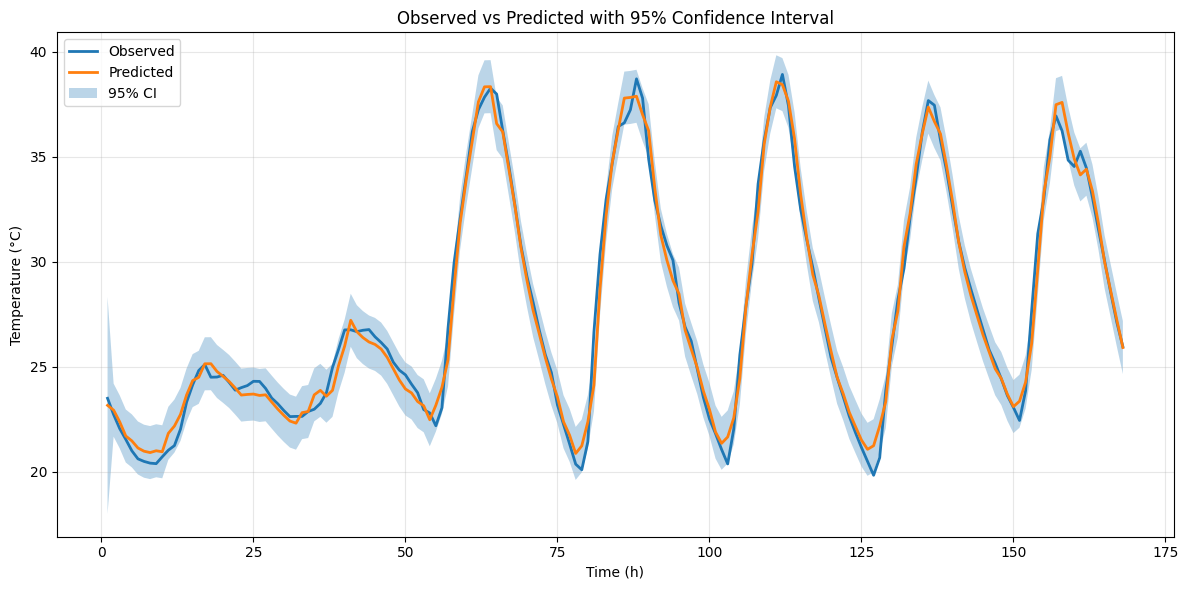

In [10]:
# ==========================================================
# FILTER + 95% CONFIDENCE INTERVAL FOR PREDICTION
# ==========================================================

def run_filter_with_ci(par, df):
    A      = par[0]
    B      = np.array(par[1:4]).reshape(1,3)
    G      = abs(par[4])
    C      = par[5]
    sigma_y = abs(par[6])
    x0     = par[7]

    Q = np.array([[G**2]])
    R = np.array([[sigma_y**2]])

    Y = df["Y"].values.reshape(-1,1)
    U = df[["Ta","S","I"]].values

    Tn = len(df)

    x_est = np.array([[x0]])
    P_est = np.array([[10.0]])

    yhat   = []
    lower  = []
    upper  = []

    for t in range(Tn):

        u_t = U[t].reshape(3,1)

        # ---------------------------------
        # Prediction step
        # ---------------------------------
        x_pred = A*x_est + B @ u_t
        P_pred = A*P_est*A + Q

        # Output prediction
        y_pred = C*x_pred

        # Prediction variance of Y
        Var_y = C*P_pred*C + R
        std_y = np.sqrt(Var_y[0,0])

        # 95% confidence interval
        ci_low = y_pred[0,0] - 1.96*std_y
        ci_up  = y_pred[0,0] + 1.96*std_y

        yhat.append(y_pred[0,0])
        lower.append(ci_low)
        upper.append(ci_up)

        # ---------------------------------
        # Update step with observation
        # ---------------------------------
        y_t = Y[t].reshape(1,1)

        innov = y_t - y_pred
        S_t = Var_y

        K = P_pred*C/S_t

        x_est = x_pred + K @ innov
        P_est = (1-K*C)*P_pred

    return np.array(yhat), np.array(lower), np.array(upper)


# ==========================================================
# RUN MODEL
# ==========================================================
df["Yhat"], df["CI_low"], df["CI_up"] = run_filter_with_ci(res.x, df)

# ==========================================================
# PLOT WITH 95% CI
# ==========================================================
plt.figure(figsize=(12,6))

plt.plot(df["time"], df["Y"], label="Observed", linewidth=2)
plt.plot(df["time"], df["Yhat"], label="Predicted", linewidth=2)

plt.fill_between(
    df["time"],
    df["CI_low"],
    df["CI_up"],
    alpha=0.3,
    label="95% CI"
)

plt.xlabel("Time (h)")
plt.ylabel("Temperature (°C)")
plt.title("Observed vs Predicted with 95% Confidence Interval")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# ==========================================================
# TABLE OF PREDICTIONS + 95% CONFIDENCE INTERVALS
# ==========================================================

# Run model
df["Yhat"], df["CI_low"], df["CI_up"] = run_filter_with_ci(res.x, df)

# Create results table
results_table = pd.DataFrame({
    "Time": df["time"],
    "Observed_Y": df["Y"],
    "Predicted_Yhat": df["Yhat"],
    "CI Lower 95%": df["CI_low"],
    "CI Upper 95%": df["CI_up"],
})

# Show full table
print(results_table)

# ==========================================================
# OPTIONAL: ROUND VALUES
# ==========================================================
print("\nRounded Table:\n")
print(results_table.round(3))



     Time  Observed_Y  Predicted_Yhat  CI Lower 95%  CI Upper 95%
0       1   23.496733       23.161450     17.994544     28.328357
1       2   22.720333       22.931553     21.668542     24.194564
2       3   22.052700       22.375313     21.112302     23.638324
3       4   21.538050       21.700152     20.437141     22.963163
4       5   20.995033       21.467755     20.204744     22.730767
..    ...         ...             ...           ...           ...
163   164   31.510183       31.803333     30.540322     33.066345
164   165   30.037760       29.979538     28.716527     31.242550
165   166   28.530450       28.614693     27.351681     29.877704
166   167   27.118660       27.233498     25.970487     28.496509
167   168   25.956717       25.913066     24.650055     27.176077

[168 rows x 5 columns]

Rounded Table:

     Time  Observed_Y  Predicted_Yhat  CI Lower 95%  CI Upper 95%
0       1      23.497          23.161        17.995        28.328
1       2      22.720          22.9

Optimization success: False
Estimated parameters:
[ 2.81708299e+00  3.06579345e+00 -1.88947362e+00 -2.04879438e+00
 -1.76512931e-01 -3.09323926e-03 -8.96697666e-01  2.76010986e-01
  4.97873158e-03  1.09593867e+00  4.72246397e-01  7.98117925e-01
  7.12265815e-01  8.22661753e-03  2.35833896e+01  3.52066280e-02]

A:
 [[ 2.81708299  3.06579345]
 [-1.88947362 -2.04879438]]
B:
 [[-0.17651293 -0.00309324 -0.89669767]
 [ 0.27601099  0.00497873  1.09593867]]
G: 0.472246397409283
C: [[0.79811792 0.71226581]]
sigma_y: 0.008226617529901593


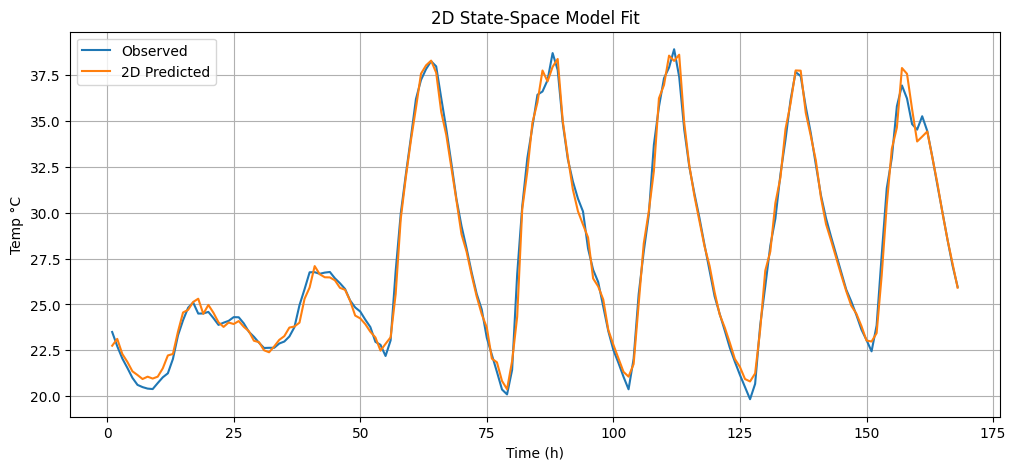

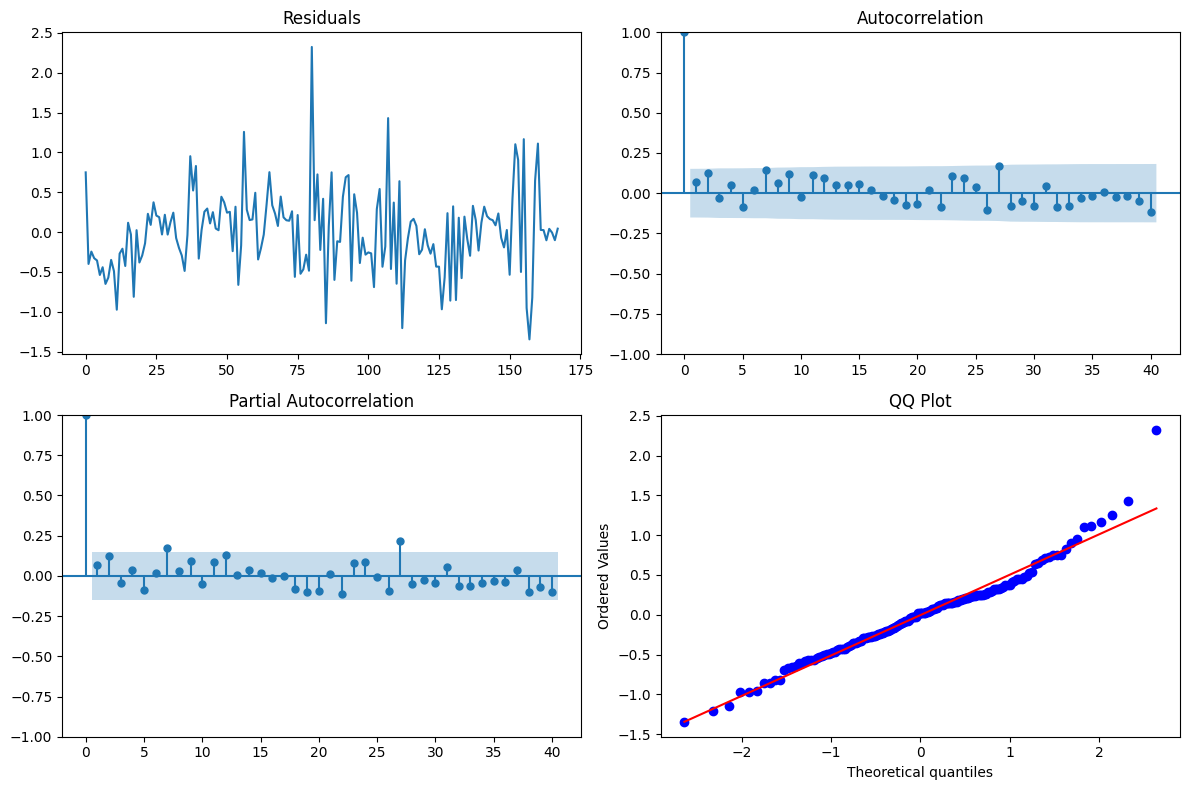


LogLik = -126.27618492743763
AIC = 284.5523698548752
BIC = 334.5357935253274


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import probplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==========================================================
# LOAD DATA
# ==========================================================
df = pd.read_csv("transformer_data.csv")

t = df["time"].values
Y = df["Y"].values.reshape(-1, 1)
U = df[["Ta", "S", "I"]].values


# ==========================================================
# 2D KALMAN LOG-LIKELIHOOD
# ==========================================================
def kalman_loglik(par, df):

    # -------------------------
    # PARAMETERS
    # -------------------------
    A = np.array(par[0:4]).reshape(2,2)
    B = np.array(par[4:10]).reshape(2,3)

    G = abs(par[10])
    C = np.array(par[11:13]).reshape(1,2)

    sigma_y = abs(par[13])
    x0 = np.array(par[14:16]).reshape(2,1)

    # Covariances
    Q = (G**2) * np.eye(2)
    R = np.array([[sigma_y**2]])

    Y = df["Y"].values.reshape(-1,1)
    U = df[["Ta","S","I"]].values

    Tn = len(df)

    # Initial state
    x_est = x0
    P_est = np.eye(2) * 10

    logLik = 0.0

    # -------------------------
    # KALMAN FILTER
    # -------------------------
    for t in range(Tn):

        u_t = U[t].reshape(3,1)
        y_t = Y[t].reshape(1,1)

        # Prediction
        x_pred = A @ x_est + B @ u_t
        P_pred = A @ P_est @ A.T + Q

        # Innovation
        y_pred = C @ x_pred
        S_t = C @ P_pred @ C.T + R
        innov = y_t - y_pred

        logLik += -0.5 * (
            np.log(2*np.pi*S_t[0,0]) +
            (innov.T @ np.linalg.inv(S_t) @ innov)[0,0]
        )

        # Update
        K = P_pred @ C.T @ np.linalg.inv(S_t)
        x_est = x_pred + K @ innov
        P_est = (np.eye(2) - K @ C) @ P_pred

    return logLik


# ==========================================================
# OPTIMIZATION
# ==========================================================
def estimate_dt(start_par, df):

    def objective(par):
        return -kalman_loglik(par, df)

    result = minimize(objective, x0=start_par, method="L-BFGS-B")
    return result


# ==========================================================
# INITIAL GUESS
# ==========================================================
start_par = np.array([

    # A (2x2)
    0.9, 0.05,
    0.0, 0.8,

    # B (2x3)
    0.2, 0.01, 0.5,
    0.1, 0.01, 0.5,

    # G
    1.0,

    # C (1x2)
    1.0, 0.5,

    # sigma_y
    1.0,

    # x0
    Y[0,0], 0.0
])

res = estimate_dt(start_par, df)

print("Optimization success:", res.success)
print("Estimated parameters:")
print(res.x)


# ==========================================================
# EXTRACT PARAMETERS
# ==========================================================
A = res.x[0:4].reshape(2,2)
B = res.x[4:10].reshape(2,3)
G = abs(res.x[10])
C = res.x[11:13].reshape(1,2)
sigmaY = abs(res.x[13])
x0 = res.x[14:16]

print("\nA:\n", A)
print("B:\n", B)
print("G:", G)
print("C:", C)
print("sigma_y:", sigmaY)


# ==========================================================
# FILTER (FITTED VALUES)
# ==========================================================
def run_filter(par, df):

    A = np.array(par[0:4]).reshape(2,2)
    B = np.array(par[4:10]).reshape(2,3)
    G = abs(par[10])
    C = np.array(par[11:13]).reshape(1,2)
    sigma_y = abs(par[13])
    x = np.array(par[14:16]).reshape(2,1)

    Q = (G**2) * np.eye(2)
    R = np.array([[sigma_y**2]])

    Y = df["Y"].values.reshape(-1,1)
    U = df[["Ta","S","I"]].values

    P = np.eye(2) * 10

    yhat = []

    for t in range(len(df)):

        u_t = U[t].reshape(3,1)

        # Prediction
        x_pred = A @ x + B @ u_t
        P_pred = A @ P @ A.T + Q

        y_pred = C @ x_pred
        yhat.append(y_pred[0,0])

        # Update
        S = C @ P_pred @ C.T + R
        K = P_pred @ C.T @ np.linalg.inv(S)

        innov = Y[t].reshape(1,1) - y_pred

        x = x_pred + K @ innov
        P = (np.eye(2) - K @ C) @ P_pred

    return np.array(yhat)


df["Yhat"] = run_filter(res.x, df)
df["resid"] = df["Y"] - df["Yhat"]


# ==========================================================
# PLOT FIT
# ==========================================================
plt.figure(figsize=(12,5))
plt.plot(df["time"], df["Y"], label="Observed")
plt.plot(df["time"], df["Yhat"], label="2D Predicted")
plt.legend()
plt.title("2D State-Space Model Fit")
plt.xlabel("Time (h)")
plt.ylabel("Temp °C")
plt.grid()
plt.show()


# ==========================================================
# RESIDUAL DIAGNOSTICS
# ==========================================================
fig, axs = plt.subplots(2,2, figsize=(12,8))

axs[0,0].plot(df["resid"])
axs[0,0].set_title("Residuals")

plot_acf(df["resid"], ax=axs[0,1], lags=40)
plot_pacf(df["resid"], ax=axs[1,0], lags=40)

probplot(df["resid"], dist="norm", plot=axs[1,1])
axs[1,1].set_title("QQ Plot")

plt.tight_layout()
plt.show()


# ==========================================================
# AIC / BIC
# ==========================================================
k = len(res.x)
n = len(df)

logLik = kalman_loglik(res.x, df)

AIC = 2*k - 2*logLik
BIC = np.log(n)*k - 2*logLik

print("\nLogLik =", logLik)
print("AIC =", AIC)
print("BIC =", BIC)

In [13]:
def run_filter_with_ci(par, df):

    # -------------------------
    # PARAMETERS (2D)
    # -------------------------
    A = np.array(par[0:4]).reshape(2,2)
    B = np.array(par[4:10]).reshape(2,3)

    G = abs(par[10])
    C = np.array(par[11:13]).reshape(1,2)

    sigma_y = abs(par[13])
    x = np.array(par[14:16]).reshape(2,1)

    # Covariances
    Q = (G**2) * np.eye(2)
    R = np.array([[sigma_y**2]])

    # Data
    Y = df["Y"].values.reshape(-1,1)
    U = df[["Ta","S","I"]].values

    Tn = len(df)

    # Initial covariance
    P = np.eye(2) * 10

    # Outputs
    yhat  = []
    lower = []
    upper = []

    # =========================
    # KALMAN FILTER
    # =========================
    for t in range(Tn):

        u_t = U[t].reshape(3,1)

        # ---------------------
        # Prediction step
        # ---------------------
        x_pred = A @ x + B @ u_t
        P_pred = A @ P @ A.T + Q

        # Output prediction
        y_pred = C @ x_pred

        # Uncertainty of output
        Var_y = C @ P_pred @ C.T + R
        std_y = np.sqrt(Var_y[0,0])

        ci_low = y_pred[0,0] - 1.96 * std_y
        ci_up  = y_pred[0,0] + 1.96 * std_y

        yhat.append(y_pred[0,0])
        lower.append(ci_low)
        upper.append(ci_up)

        # ---------------------
        # Update step
        # ---------------------
        y_t = Y[t].reshape(1,1)

        innov = y_t - y_pred
        S_t = Var_y

        K = P_pred @ C.T @ np.linalg.inv(S_t)

        x = x_pred + K @ innov
        P = (np.eye(2) - K @ C) @ P_pred

    return np.array(yhat), np.array(lower), np.array(upper)

In [14]:
df["Yhat"], df["CI_low"], df["CI_up"] = run_filter_with_ci(res.x, df)

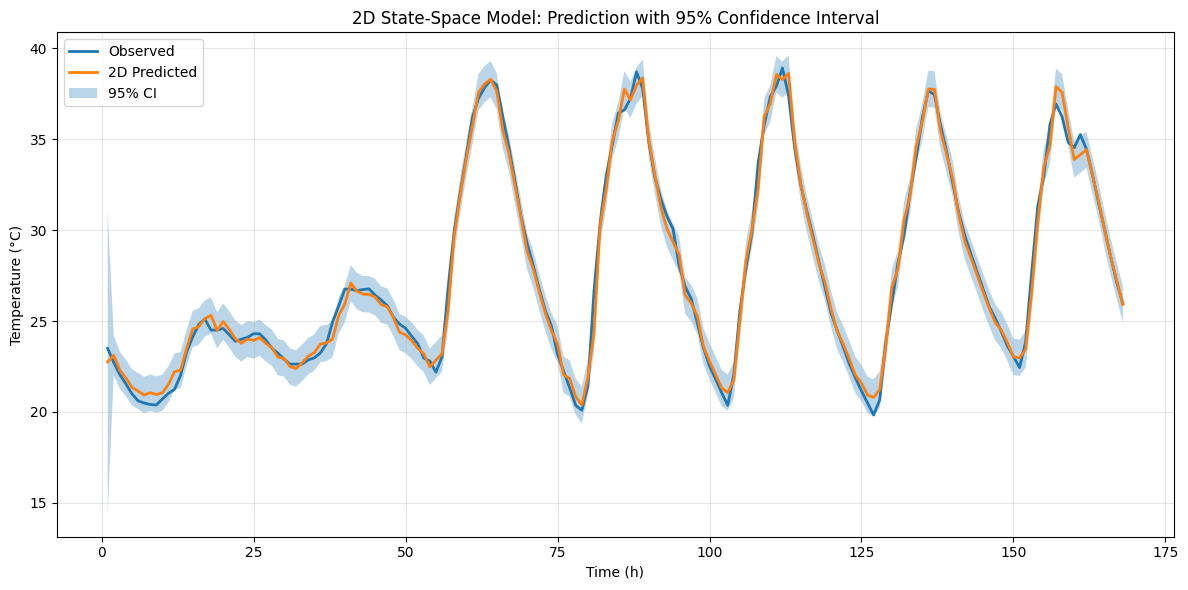

In [15]:
plt.figure(figsize=(12,6))

plt.plot(df["time"], df["Y"], label="Observed", linewidth=2)
plt.plot(df["time"], df["Yhat"], label="2D Predicted", linewidth=2)

plt.fill_between(
    df["time"],
    df["CI_low"],
    df["CI_up"],
    alpha=0.3,
    label="95% CI"
)

plt.xlabel("Time (h)")
plt.ylabel("Temperature (°C)")
plt.title("2D State-Space Model: Prediction with 95% Confidence Interval")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
def run_filter_states(par, df):

    A = np.array(par[0:4]).reshape(2,2)
    B = np.array(par[4:10]).reshape(2,3)
    G = abs(par[10])
    C = np.array(par[11:13]).reshape(1,2)
    sigma_y = abs(par[13])
    x = np.array(par[14:16]).reshape(2,1)

    Q = (G**2) * np.eye(2)
    R = np.array([[sigma_y**2]])

    Y = df["Y"].values.reshape(-1,1)
    U = df[["Ta","S","I"]].values

    P = np.eye(2) * 10

    yhat = []
    states = []

    for t in range(len(df)):

        u_t = U[t].reshape(3,1)

        # Prediction
        x_pred = A @ x + B @ u_t
        P_pred = A @ P @ A.T + Q

        y_pred = C @ x_pred
        yhat.append(y_pred[0,0])

        # Update
        S = C @ P_pred @ C.T + R
        K = P_pred @ C.T @ np.linalg.inv(S)

        innov = Y[t].reshape(1,1) - y_pred

        x = x_pred + K @ innov
        P = (np.eye(2) - K @ C) @ P_pred

        states.append(x.flatten())

    return np.array(yhat), np.array(states)

In [17]:
df["Yhat"], Xhat = run_filter_states(res.x, df)

df["x1"] = Xhat[:,0]
df["x2"] = Xhat[:,1]

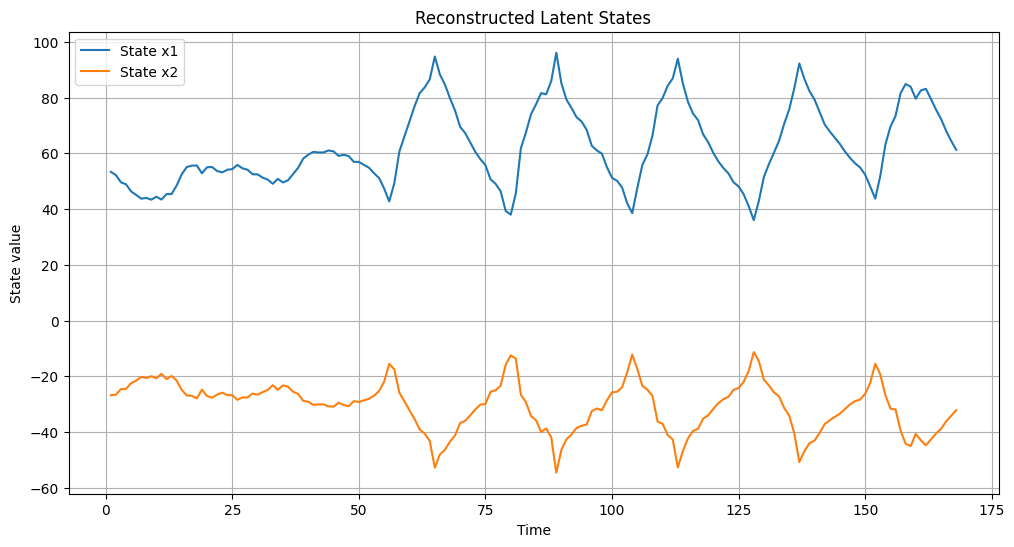

In [18]:
plt.figure(figsize=(12,6))
plt.plot(df["time"], df["x1"], label="State x1")
plt.plot(df["time"], df["x2"], label="State x2")
plt.title("Reconstructed Latent States")
plt.xlabel("Time")
plt.ylabel("State value")
plt.legend()
plt.grid()
plt.show()

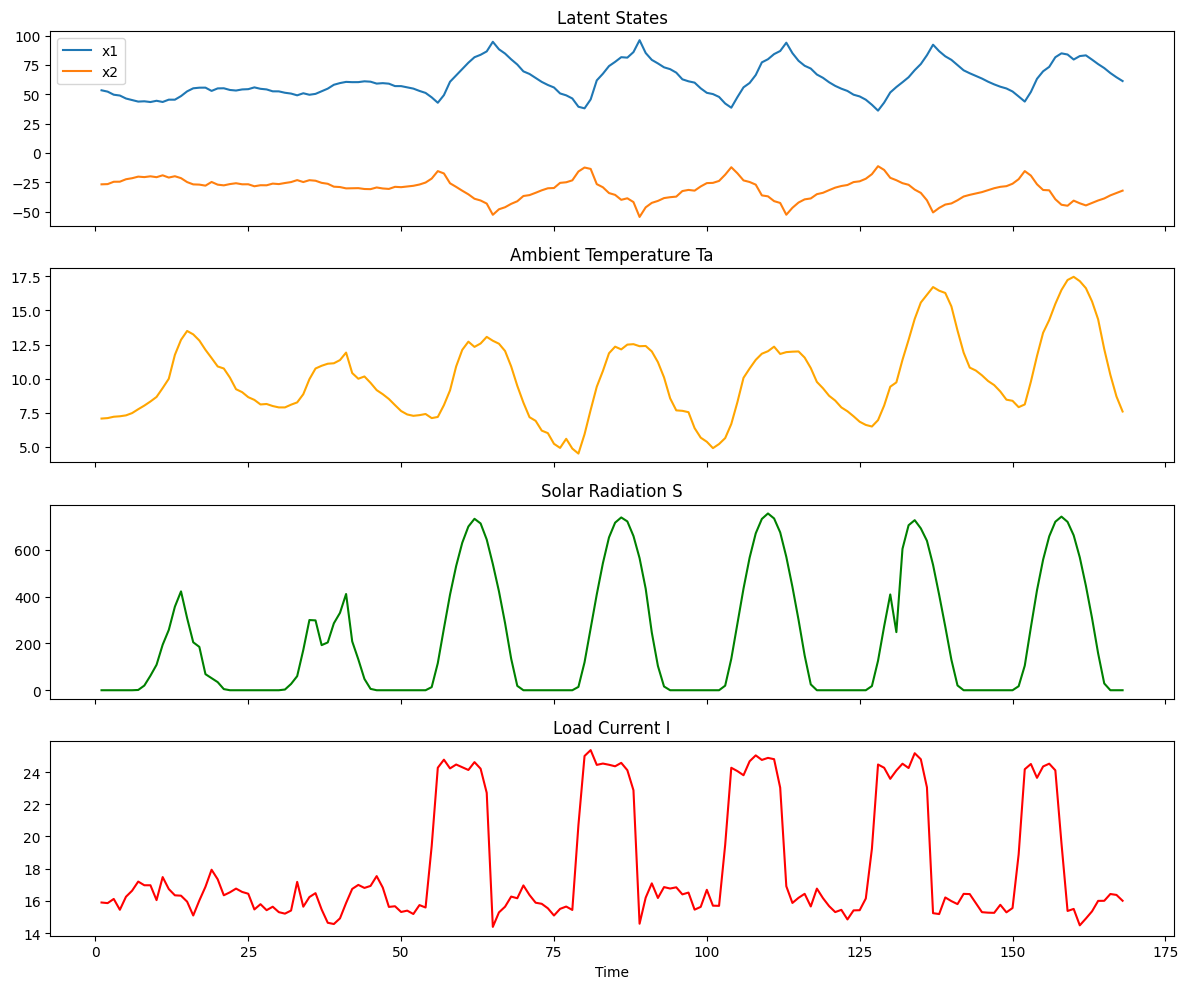

In [19]:
fig, axs = plt.subplots(4,1, figsize=(12,10), sharex=True)

axs[0].plot(df["time"], df["x1"], label="x1")
axs[0].plot(df["time"], df["x2"], label="x2")
axs[0].legend()
axs[0].set_title("Latent States")

axs[1].plot(df["time"], df["Ta"], color='orange')
axs[1].set_title("Ambient Temperature Ta")

axs[2].plot(df["time"], df["S"], color='green')
axs[2].set_title("Solar Radiation S")

axs[3].plot(df["time"], df["I"], color='red')
axs[3].set_title("Load Current I")

plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [20]:
print(A)

[[ 2.81708299  3.06579345]
 [-1.88947362 -2.04879438]]


In [21]:
print(B)

[[-0.17651293 -0.00309324 -0.89669767]
 [ 0.27601099  0.00497873  1.09593867]]
